In [21]:
import pandas as pd
import numpy as np
import os
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV
from functools import reduce
import random
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import LeaveOneOut, cross_val_score


from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.utils import to_categorical

import pickle

### Overview #2
Prepares the input data for model training. It processes the summary statistics folder, which contains files for seven extracted features, and consolidates the data into a single DataFrame. The resulting DataFrame includes columns for Subject ID, Session ID, Trial ID, and Gesture (the target variable for prediction), while the remaining columns represent the summary statistics for all extracted features.

In [22]:
data_folder = os.path.join('..', 'MachineLearning', 'SummaryStatistics')

# Initialize a df to add ALL FEATURES into one df
cumulative_df = None


for feature_file in sorted(os.listdir(data_folder)):
    feature = feature_file[:-9]

    df = pd.read_csv(os.path.join(data_folder, feature_file))

    # Rename columns related to left (L) and right (R) hands to include the feature name
    df = df.rename(columns={
        col: f"{feature}_{col}" for col in df.columns if col.startswith('L-') or col.startswith('R-')
    })

    # Merge DataFrames based on primary keys
    if cumulative_df is None:
        # First DataFrame becomes the base
        cumulative_df = df
    else:
        # Merge on primary keys + Gesture & Label to avoid duplicating them
        cumulative_df = pd.merge(
            cumulative_df, 
            df, 
            on=['SubID', 'SessionID', 'TrialID', 'Gesture', 'Label'], 
            how='inner'
        )

# Get the list of current columns
cols = list(cumulative_df.columns)

# Remove 'Gesture' from its current position
cols.remove('Gesture')
cols.remove('Label')

# Insert 'Gesture' at the 4th position after the subject, session, trial id
cols.insert(3, 'Gesture')

# Reorder the DataFrame
cumulative_df = cumulative_df[cols]

print(len(cumulative_df))

2083


In [23]:
# Convert Gesture text value to numeric
gesture_label_encoder = LabelEncoder()
gesture_encoded = gesture_label_encoder.fit_transform(cumulative_df['Gesture'])

cumulative_df['Gesture'] = gesture_encoded

# Display the mapping of original gestures to encoded labels
for index, label in enumerate(gesture_label_encoder.classes_):
    print(f"{index} → {label}")

0 → PanDown
1 → PanLeft
2 → PanRight
3 → PanUp
4 → RotBackX
5 → RotClockwiseY
6 → RotCounterY
7 → RotForwardX
8 → RotLeftZ
9 → RotRightZ
10 → ZoomIn
11 → ZoomOut


### Overview #3

Prepares data by separating into training and testing (with two participant selected).

#### Variables:
* data_df: Used for training/testing
* validation_df: Used to introduce the model to unseen data after training/testing; Two subject sessions

In [24]:
# Keep primary keys for reference
primary_keys = ['SubID', 'SessionID', 'TrialID']
primary_key_df = cumulative_df[primary_keys]  # Store primary keys separately

# Prepare test data
X = cumulative_df.drop(['Gesture'], axis=1)  # All columns except 'Gesture' and primary keys
y = cumulative_df['Gesture']

In [43]:
random.seed(42)

# Group data by Subject ID and Session ID
grouped = X.groupby(['SubID', 'SessionID'])

# Get unique group keys (Subject ID, Session ID)
unique_groups = sorted(list(grouped.groups.keys()))

# Perform train-test split on unique groups
train_groups, test_groups = train_test_split(unique_groups, test_size=0.2, random_state=42)

# Create train and test sets by selecting corresponding rows
X_train = X[X.set_index(['SubID', 'SessionID']).index.isin(train_groups)]
X_test = X[X.set_index(['SubID', 'SessionID']).index.isin(test_groups)]
y_train = y.loc[X_train.index]
y_test = y.loc[X_test.index]

# Track the original indices
idx_train = X_train.index
idx_test = X_test.index

# Display results
print("Train Groups:", len(train_groups))
print("Test Groups:", len(test_groups))
print("Train Samples:", X_train.shape[0])
print("Test Samples:", X_test.shape[0])

#print(X_train[['SubID', 'SessionID']].drop_duplicates())
print(X_test[['SubID', 'SessionID']].drop_duplicates())

Train Groups: 28
Test Groups: 8
Train Samples: 1614
Test Samples: 469
     SubID  SessionID
55    11.0        1.0
60    11.0        2.0
75    13.0        1.0
100   16.0        1.0
124   18.0        1.0
139   21.0        1.0
144   22.0        1.0
164   26.0        1.0


Select two participants from the test data

In [26]:
# For reproducability
random.seed(40)

# Group X and y
X_grouped = list(X_test.groupby(['SubID', 'SessionID']))
y_grouped = {key: y.loc[group.index] for key, group in X_grouped}

# Choose two subject sessions from X_test
random_indices = random.sample(range(len(X_grouped)), 2)

# Extract the corresponding groups
second_X_test = pd.concat([X_grouped[i][1] for i in random_indices], ignore_index=True)
second_y_test = pd.concat([y_grouped[X_grouped[i][0]] for i in random_indices], ignore_index=True)

print(second_X_test)
print(second_y_test)


     SubID  SessionID  TrialID  Acceleration_L-U_Min  Acceleration_L-V_Min  \
0     23.0        1.0      1.0             -6.246549             -6.002244   
1     23.0        1.0      2.0             -5.025430             -6.172039   
2     23.0        1.0      3.0             -6.178221             -6.166948   
3     23.0        1.0      4.0             -5.999874             -6.178788   
4     23.0        1.0      5.0             -6.004884             -6.625670   
..     ...        ...      ...                   ...                   ...   
115   13.0        1.0      1.0             16.992064            -41.306083   
116   13.0        1.0      2.0             27.126836            -14.830196   
117   13.0        1.0      3.0             32.864540            -22.135925   
118   13.0        1.0      4.0             27.903282            -15.903425   
119   13.0        1.0      5.0             35.353076            -59.048045   

     Acceleration_L-W_Min  Acceleration_L-U_Max  Acceleration_L

In [27]:
X_train = X_train.drop(primary_keys, axis=1)
X_test = X_test.drop(primary_keys, axis=1)
second_X_test = second_X_test.drop(primary_keys, axis=1)

### Overview #4

Random Forest Model.

* Implements a grid search for the best hyperparameters.
* Set up model.
* Train and test model.
* Print out reports and graphs of results.
* Check with validation dataset

In [ ]:
# Hyperparameters for grid search
grid = {
    'n_estimators': [200, 250, 300, 350],
    'max_features': ['sqrt', 'log2'],
    'max_depth' : [6, 8, 10, 12, 14, 16, 18],
    'criterion' :['gini', 'entropy'],
    'random_state' : [42]
}

rf_cv = GridSearchCV(estimator=RandomForestClassifier(), param_grid=grid, cv= 5)
rf_cv.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [10, 12, 14, 16, 18],
                         'max_features': ['sqrt', 'log2'],
                         'n_estimators': [200, 250, 300, 350],
                         'random_state': [42]})

In [104]:
rf_cv.best_params_

{'criterion': 'entropy',
 'max_depth': 10,
 'max_features': 'log2',
 'n_estimators': 250,
 'random_state': 42}

In [40]:
rf_model = RandomForestClassifier(
    n_estimators=350,    # Number of trees
    max_depth=12,      # Let trees grow fully
    random_state=40,
    max_features='sqrt',
    oob_score=True,
    min_samples_split=2,  
    criterion='gini'
)

rf_model.fit(X_train, y_train)

KeyboardInterrupt: 

In [39]:
y_pred = rf_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=gesture_label_encoder.classes_))
#.8336

Accuracy: 0.7896995708154506
               precision    recall  f1-score   support

      PanDown       0.73      1.00      0.84        40
      PanLeft       0.76      0.95      0.84        40
     PanRight       0.88      0.90      0.89        39
        PanUp       0.81      0.97      0.88        39
     RotBackX       0.77      0.75      0.76        40
RotClockwiseY       0.88      0.75      0.81        40
  RotCounterY       0.84      0.82      0.83        39
  RotForwardX       0.78      0.62      0.69        40
     RotLeftZ       0.66      0.62      0.64        40
    RotRightZ       0.63      0.44      0.52        39
       ZoomIn       0.88      0.80      0.84        35
      ZoomOut       0.88      0.86      0.87        35

     accuracy                           0.79       466
    macro avg       0.79      0.79      0.78       466
 weighted avg       0.79      0.79      0.78       466



In [ ]:
file_path = os.path.join('..', 'MachineLearning', 'Models', 'rf_model.pkl')

# Save the trained model as a .pkl file
with open(file_path, "wb") as file:
    pickle.dump(rf_model, file)

In [42]:
with open(file_path, "rb") as file:
    loaded_model = pickle.load(file)
    print(loaded_model.feature_names_in_)

['Acceleration_L-U_Min' 'Acceleration_L-V_Min' 'Acceleration_L-W_Min'
 'Acceleration_L-U_Max' 'Acceleration_L-V_Max' 'Acceleration_L-W_Max'
 'Acceleration_L-U_Mean' 'Acceleration_L-V_Mean' 'Acceleration_L-W_Mean'
 'Acceleration_L-U_Std' 'Acceleration_L-V_Std' 'Acceleration_L-W_Std'
 'Acceleration_R-U_Min' 'Acceleration_R-V_Min' 'Acceleration_R-W_Min'
 'Acceleration_R-U_Max' 'Acceleration_R-V_Max' 'Acceleration_R-W_Max'
 'Acceleration_R-U_Mean' 'Acceleration_R-V_Mean' 'Acceleration_R-W_Mean'
 'Acceleration_R-U_Std' 'Acceleration_R-V_Std' 'Acceleration_R-W_Std'
 'Angle_L-Min' 'Angle_L-Max' 'Angle_L-Mean' 'Angle_L-Std' 'Angle_R-Min'
 'Angle_R-Max' 'Angle_R-Mean' 'Angle_R-Std' 'Curvature_L-Min'
 'Curvature_L-Max' 'Curvature_L-Mean' 'Curvature_L-Std' 'Curvature_R-Min'
 'Curvature_R-Max' 'Curvature_R-Mean' 'Curvature_R-Std' 'Time'
 'Length_L-Min' 'Length_L-Max' 'Length_L-Mean' 'Length_L-Std'
 'Length_R-Min' 'Length_R-Max' 'Length_R-Mean' 'Length_R-Std'
 'Speed_L-Min' 'Speed_L-Max' 'Speed_L-M

Second accuracy test but on two unseen data

In [43]:
second_y_pred = rf_model.predict(second_X_test)

# Get unique classes from BOTH test labels and predictions
unique_classes = np.unique(np.concatenate((second_y_test, second_y_pred)))

# Map them to class names from `gesture_label_encoder`
filtered_target_names = [gesture_label_encoder.classes_[i] for i in unique_classes]

print("Accuracy:", accuracy_score(second_y_test, second_y_pred))
print(classification_report(second_y_test, second_y_pred, target_names=filtered_target_names))

Accuracy: 0.9416666666666667
               precision    recall  f1-score   support

      PanDown       0.91      1.00      0.95        10
      PanLeft       1.00      1.00      1.00        10
     PanRight       1.00      1.00      1.00        10
        PanUp       1.00      0.70      0.82        10
     RotBackX       1.00      0.60      0.75        10
RotClockwiseY       1.00      1.00      1.00        10
  RotCounterY       1.00      1.00      1.00        10
  RotForwardX       0.62      1.00      0.77        10
     RotLeftZ       1.00      1.00      1.00        10
    RotRightZ       1.00      1.00      1.00        10
       ZoomIn       1.00      1.00      1.00        10
      ZoomOut       1.00      1.00      1.00        10

     accuracy                           0.94       120
    macro avg       0.96      0.94      0.94       120
 weighted avg       0.96      0.94      0.94       120



In [195]:
loo = LeaveOneOut()  # Leave-One-Out cross-validator

# Perform LOOCV and compute accuracy scores
loo_scores = cross_val_score(rf_model, X_train, y_train, cv=loo, scoring='accuracy')

# Print average LOOCV accuracy
print(f"LOOCV Accuracy: {np.mean(loo_scores):.4f}")

LOOCV Accuracy: 0.8947


<Figure size 1200x600 with 0 Axes>

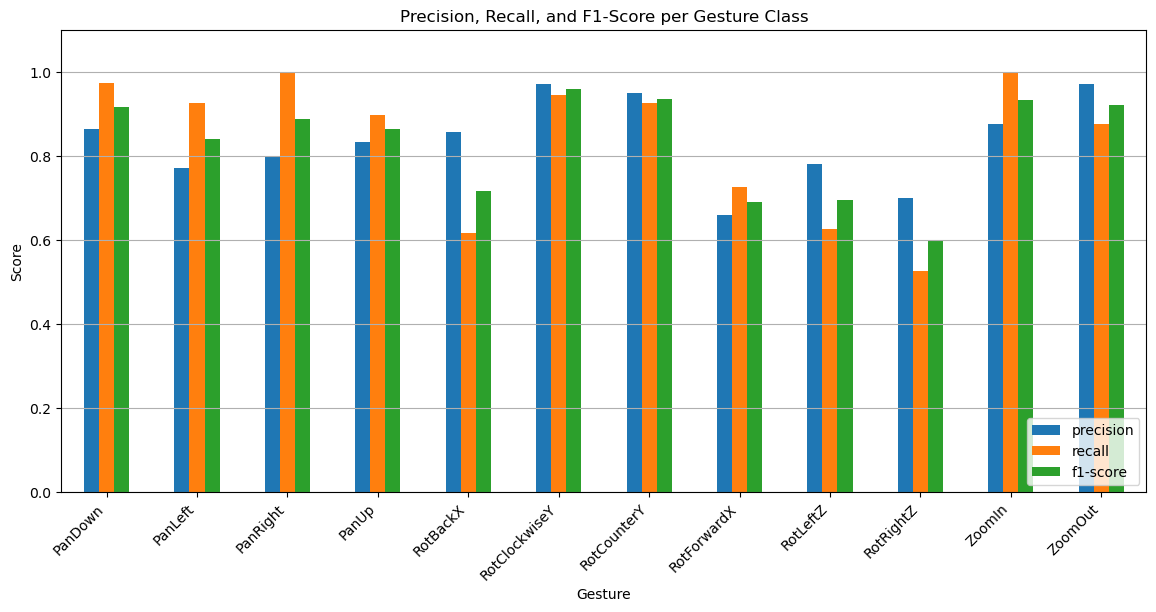

In [44]:
# Plotting precision, recall, and f1-score
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()

# Remove accuracy, macro avg, and weighted avg rows
report_df = report_df.iloc[:-3, :]

# Set up figures
plt.figure(figsize=(12, 6))
ax = report_df[['precision', 'recall', 'f1-score']].plot(kind='bar', figsize=(14, 6))

# Set x-tick positions and labels correctly
ax.set_xticks(range(len(gesture_label_encoder.classes_)))  # Assign numerical positions
ax.set_xticklabels(gesture_label_encoder.classes_, rotation=45, ha="right")  # Assign class labels

# Modify setup
plt.title("Precision, Recall, and F1-Score per Gesture Class")
plt.xlabel("Gesture")
plt.ylabel("Score")
plt.ylim(0, 1.1)
plt.grid(axis='y')
plt.legend(loc='lower right')

plt.show()

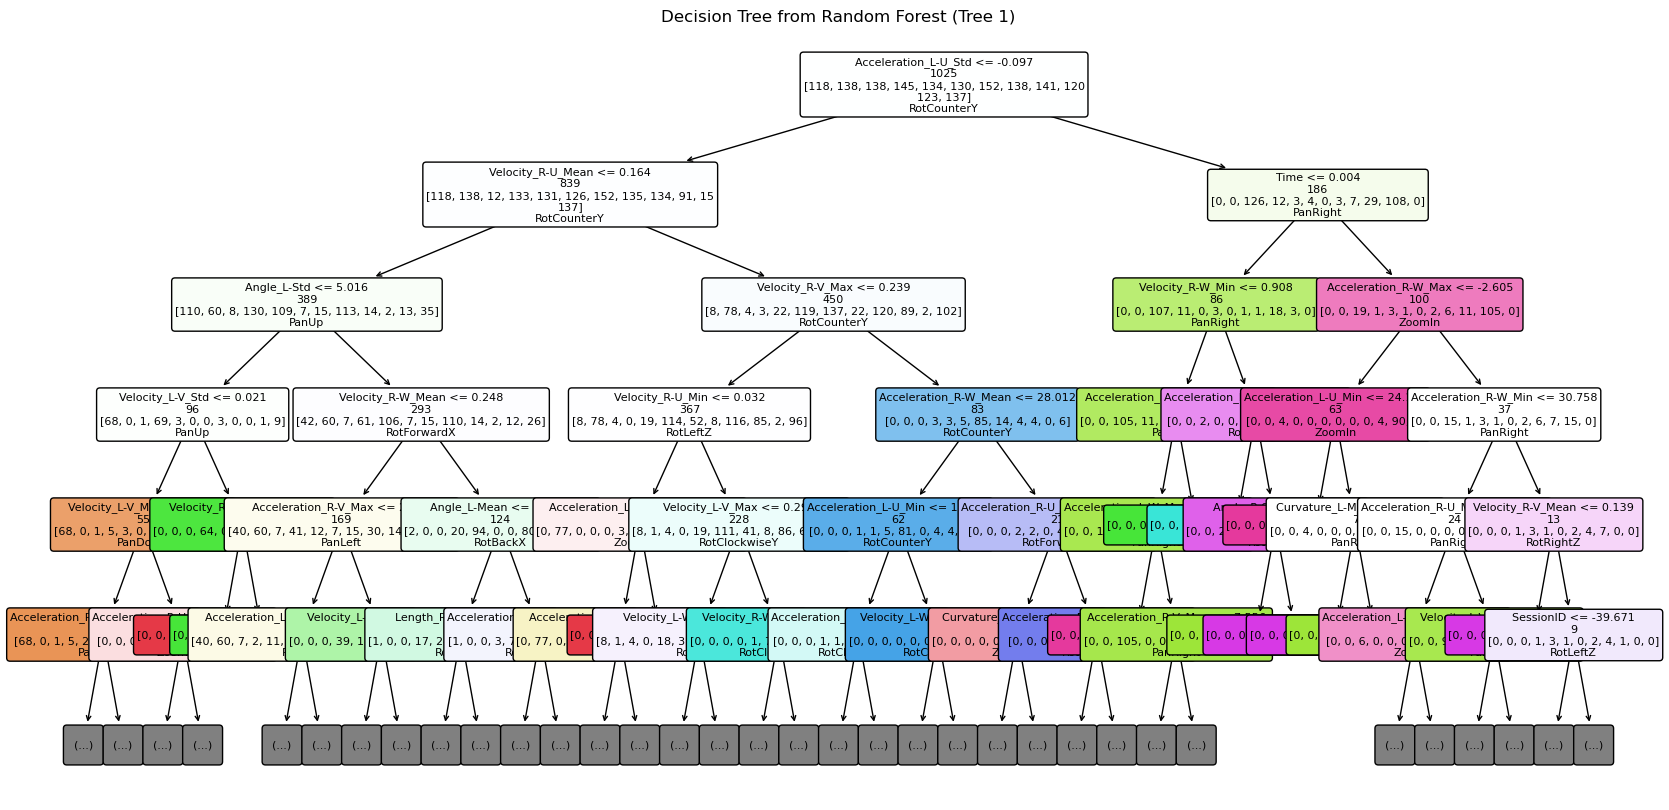

In [11]:
# Plotting a sample bootstrap tree
features = X.columns.tolist()

plt.figure(figsize=(20, 10))
plot_tree(
    rf_model.estimators_[0], 
    feature_names=features,         
    class_names=gesture_label_encoder.classes_.tolist(),
    filled=True,
    rounded=True,
    max_depth=5,
    proportion=False,  # Set to False to avoid proportions inside nodes
    impurity=False,    # Removes Gini values
    label="none",       # Removes feature values
    fontsize=8
)
plt.title("Decision Tree from Random Forest (Tree 1)")
plt.show()


In [46]:
# Displaying list of feature importances
importances = rf_model.feature_importances_
feature_names = rf_model.feature_names_in_

# Select the top 40 most important features
top_features_indices = np.argsort(importances)[-40:]  # Indices of top 40 features
top_importances = importances[top_features_indices]   # Their importances
top_feature_names = feature_names[top_features_indices]  # Corresponding feature names

for i in reversed(range(len(top_feature_names))):  # Reverse order (highest importance first)
    print(f"{top_feature_names[i]}: {top_importances[i]:.4f}")

Velocity_R-U_Min: 0.0360
Velocity_R-V_Min: 0.0355
Acceleration_R-V_Max: 0.0334
Acceleration_R-U_Min: 0.0333
Velocity_R-V_Max: 0.0316
Velocity_R-U_Mean: 0.0304
Acceleration_R-V_Min: 0.0302
Acceleration_R-V_Mean: 0.0302
Acceleration_R-U_Mean: 0.0296
Velocity_R-U_Max: 0.0294
Velocity_R-V_Mean: 0.0283
Velocity_R-W_Mean: 0.0274
Acceleration_R-U_Max: 0.0269
Acceleration_L-U_Mean: 0.0264
Acceleration_R-W_Mean: 0.0253
Velocity_L-U_Mean: 0.0251
Acceleration_R-U_Std: 0.0202
Velocity_R-U_Std: 0.0194
Velocity_R-V_Std: 0.0183
Velocity_L-U_Min: 0.0179
Acceleration_R-V_Std: 0.0176
Velocity_L-U_Max: 0.0174
Acceleration_L-U_Max: 0.0173
Acceleration_L-U_Min: 0.0168
Velocity_R-W_Max: 0.0165
Acceleration_R-W_Max: 0.0159
Velocity_L-V_Mean: 0.0144
Velocity_R-W_Min: 0.0143
Acceleration_R-W_Min: 0.0138
Acceleration_L-W_Mean: 0.0136
Acceleration_L-V_Mean: 0.0133
Velocity_L-W_Mean: 0.0127
Velocity_L-V_Max: 0.0108
Velocity_R-W_Std: 0.0098
Acceleration_L-V_Max: 0.0097
Velocity_L-V_Min: 0.0094
Acceleration_L-W_Max

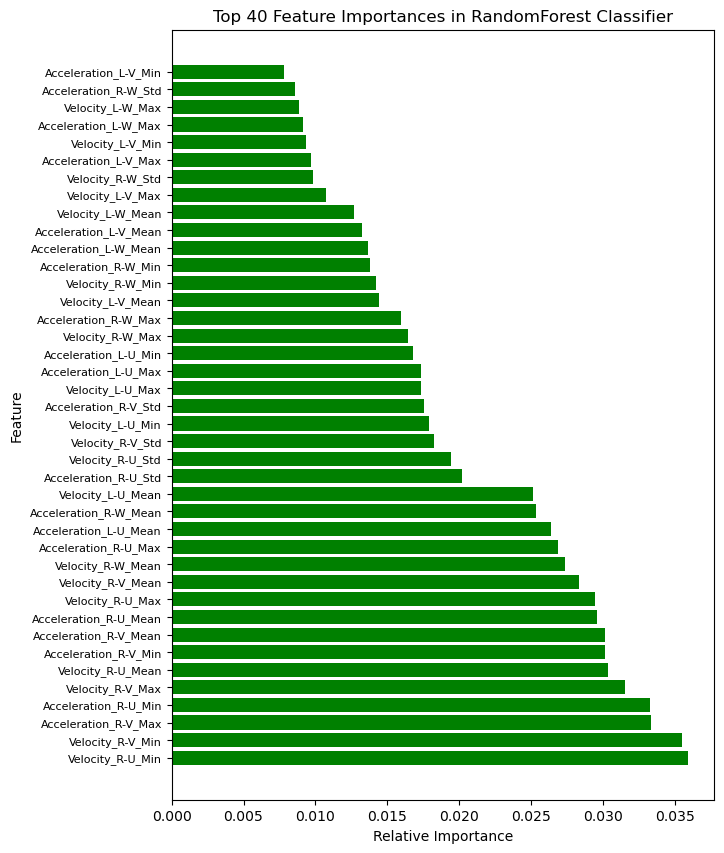

In [47]:
# Plotting only the top 40 feature importances
fig, ax = plt.subplots(figsize=(7, 10))  # Adjust figure size for better readability
ax.barh(range(len(top_importances)), top_importances, color='green')
ax.set_yticks(range(len(top_feature_names)))
ax.set_yticklabels(top_feature_names, fontsize=8)  # Adjust font size for readability
plt.title('Top 40 Feature Importances in RandomForest Classifier')
plt.xlabel('Relative Importance')
plt.ylabel('Feature')
plt.gca().invert_yaxis()  # Flip the order so highest importance is at the top
plt.show()

<Figure size 1000x800 with 0 Axes>

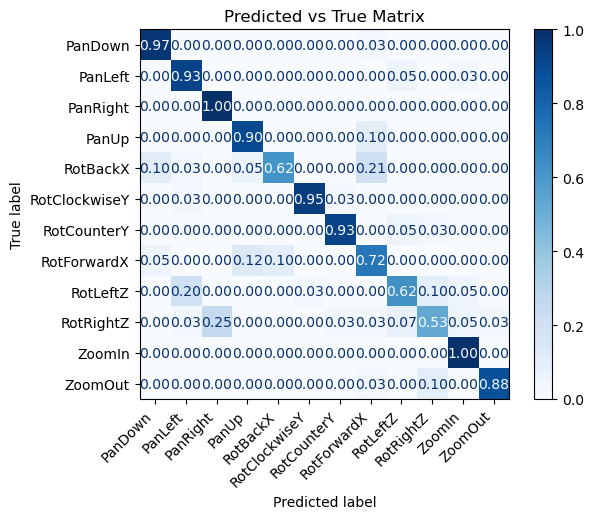

In [48]:
# Confusion matrix to display model predictions against true values
cm = confusion_matrix(y_test, y_pred, normalize='true')

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=gesture_label_encoder.classes_)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
disp.plot(cmap='Blues', values_format='.2f')
plt.xticks(rotation=45, ha="right")
plt.title('Predicted vs True Matrix')
plt.show()

In [88]:
# Identifying trials where the model predicted incorrectly

misclassified_indices = (y_pred != y_test)

misclassified_original_indices = idx_test[misclassified_indices]

# Display Misclassified Rows with Primary Keys
misclassified_df = pd.DataFrame({
    'SubID': cumulative_df.loc[misclassified_original_indices, 'SubID'].values,
    'SessionID': cumulative_df.loc[misclassified_original_indices, 'SessionID'].values,
    'TrialID': cumulative_df.loc[misclassified_original_indices, 'TrialID'].values,
    'Actual Gesture': gesture_label_encoder.inverse_transform(y_test[misclassified_indices]),
    'Predicted Gesture': gesture_label_encoder.inverse_transform(y_pred[misclassified_indices])
})

print(misclassified_df)

    SubID  SessionID  TrialID Actual Gesture Predicted Gesture
0    16.0        1.0      3.0        PanDown       RotForwardX
1    16.0        1.0      3.0        PanLeft          RotLeftZ
2    18.0        1.0      3.0        PanLeft            ZoomIn
3    21.0        1.0      1.0        PanLeft          RotLeftZ
4    11.0        1.0      5.0          PanUp       RotForwardX
..    ...        ...      ...            ...               ...
73   16.0        1.0      1.0        ZoomOut         RotRightZ
74   16.0        1.0      2.0        ZoomOut         RotRightZ
75   16.0        1.0      3.0        ZoomOut       RotForwardX
76   16.0        1.0      4.0        ZoomOut         RotRightZ
77   16.0        1.0      5.0        ZoomOut         RotRightZ

[78 rows x 5 columns]


In [49]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [304]:
# Define the parameter grid
param_grid = {
    'max_depth': [6, 9, 12],  # Tree depth
    'learning_rate': [0.1, 0.2, 0.3, 0.4],  # Step size shrinkage
    'n_estimators': [200, 250, 300, 350],  # Number of boosting rounds
    'subsample': [0.8, 1],  # Fraction of samples per tree
    'colsample_bytree': [0.8, 1],  # Fraction of features per tree
    'reg_alpha': [.1, .2, .9, 1],
    'reg_lambda': [.1, .2, .9, 1]
}

xgb_model = xgb.XGBClassifier(objective='multi:softmax', num_class=len(y_train.unique()), random_state=42)

# Perform Grid Search with 3-fold cross-validation
grid_search = GridSearchCV(
    xgb_model, 
    param_grid, 
    cv=3,  # 3-fold cross-validation
    scoring='accuracy',  # Optimize for accuracy
    n_jobs=-1,  # Use all CPU cores
    verbose=2  # Print progress
)

# Fit the GridSearch model
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 3072 candidates, totalling 9216 fits


GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None,...
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_class=12,
                                     num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 1],
                         'learning_rate': [0.1, 0.2, 0.3, 0.4],
                         'max_depth': [6, 9, 12],
                         'n_estimators': [200, 250, 300, 350],
                         'reg_alpha': [0.1, 0.2, 0.9, 1],
                         'reg_lambda': [0.1, 0.2, 0.9, 1],
                         'subsample': [0.8, 1]},
             scoring='accuracy', verbose=2)

In [306]:
best_params = grid_search.best_params_
print(best_params)

{'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 6, 'n_estimators': 350, 'reg_alpha': 0.1, 'reg_lambda': 0.9, 'subsample': 0.8}


In [124]:
# Set XGBoost parameters
params = {
    'objective': 'multi:softmax',  # For multi-class classification
    'num_class': len(gesture_label_encoder.classes_),  # Number of unique classes
    'eval_metric': 'mlogloss',  # Multi-class log loss
    'max_depth': 6,  # Maximum depth of trees
    'learning_rate': 0.4,  # Step size shrinkage
    'n_estimators': 200,  # Number of boosting rounds
    'reg_alpha': 0.08,
    'reg_lambda': .92,
    'random_state': 42
}

# Train the model
xgb_model = xgb.XGBClassifier(**params)
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.4, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_class=12, num_parallel_tree=None, ...)

In [126]:
# Make predictions
y_pred = xgb_model.predict(X_test)

# Compute accuracy
test_accuracy = accuracy_score(gesture_label_encoder.inverse_transform(y_test), gesture_label_encoder.inverse_transform(y_pred))

print(f"Test Accuracy: {test_accuracy:.4f}")
print("\nTest Classification Report:\n", classification_report(gesture_label_encoder.inverse_transform(y_test), gesture_label_encoder.inverse_transform(y_pred)))

Test Accuracy: 0.8316

Test Classification Report:
                precision    recall  f1-score   support

      PanDown       0.86      0.97      0.92        39
      PanLeft       0.78      0.90      0.84        40
     PanRight       0.78      1.00      0.88        40
        PanUp       0.86      0.82      0.84        39
     RotBackX       0.74      0.59      0.66        39
RotClockwiseY       0.90      0.97      0.94        37
  RotCounterY       0.93      0.95      0.94        40
  RotForwardX       0.59      0.65      0.62        40
     RotLeftZ       0.80      0.60      0.69        40
    RotRightZ       0.86      0.62      0.72        40
       ZoomIn       0.92      1.00      0.96        35
      ZoomOut       0.97      0.93      0.95        40

     accuracy                           0.83       469
    macro avg       0.83      0.83      0.83       469
 weighted avg       0.83      0.83      0.83       469



In [202]:
loo = LeaveOneOut()  # Leave-One-Out cross-validator

# Perform LOOCV and compute accuracy scores
loo_scores = cross_val_score(xgb_model, X_train, y_train, cv=loo, scoring='accuracy')

# Print average LOOCV accuracy
print(f"LOOCV Accuracy: {np.mean(loo_scores):.4f}")

LOOCV Accuracy: 0.8804


In [127]:
file_path = os.path.join('..', 'PreprocessedDataML', 'Models', 'xgb_model.pkl')

# Save the trained model as a .pkl file
with open(file_path, "wb") as file:
    pickle.dump(xgb_model, file)

In [128]:
second_y_pred = xgb_model.predict(second_X_test)

# Get unique classes from BOTH test labels and predictions
unique_classes = np.unique(np.concatenate((second_y_test, second_y_pred)))

# Map them to class names from `gesture_label_encoder`
filtered_target_names = [gesture_label_encoder.classes_[i] for i in unique_classes]

print("Accuracy:", accuracy_score(second_y_test, second_y_pred))
print(classification_report(second_y_test, second_y_pred, target_names=filtered_target_names))

Accuracy: 0.8666666666666667
               precision    recall  f1-score   support

      PanDown       0.91      1.00      0.95        10
      PanLeft       1.00      1.00      1.00        10
     PanRight       1.00      1.00      1.00        10
        PanUp       1.00      0.40      0.57        10
     RotBackX       0.50      0.40      0.44        10
RotClockwiseY       0.91      1.00      0.95        10
  RotCounterY       1.00      1.00      1.00        10
  RotForwardX       0.38      0.60      0.46        10
     RotLeftZ       1.00      1.00      1.00        10
    RotRightZ       1.00      1.00      1.00        10
       ZoomIn       1.00      1.00      1.00        10
      ZoomOut       1.00      1.00      1.00        10

     accuracy                           0.87       120
    macro avg       0.89      0.87      0.87       120
 weighted avg       0.89      0.87      0.87       120



<Figure size 1200x600 with 0 Axes>

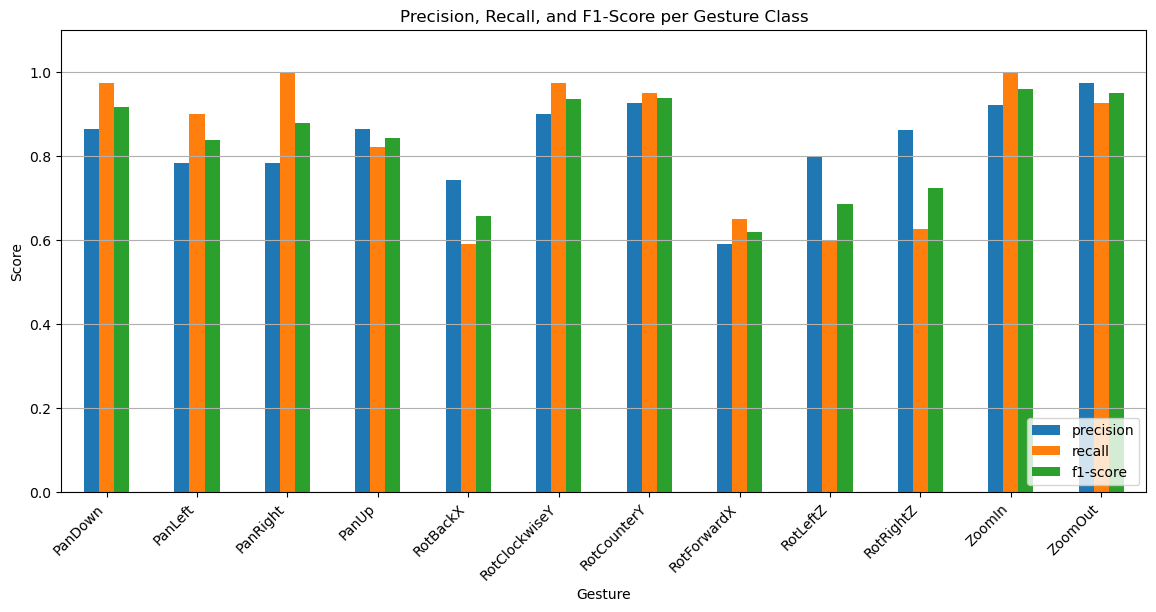

In [129]:
# Plotting precision, recall, and f1-score
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()

# Remove accuracy, macro avg, and weighted avg rows
report_df = report_df.iloc[:-3, :]

# Set up figures
plt.figure(figsize=(12, 6))
ax = report_df[['precision', 'recall', 'f1-score']].plot(kind='bar', figsize=(14, 6))

# Set x-tick positions and labels correctly
ax.set_xticks(range(len(gesture_label_encoder.classes_)))  # Assign numerical positions
ax.set_xticklabels(gesture_label_encoder.classes_, rotation=45, ha="right")  # Assign class labels

# Modify setup
plt.title("Precision, Recall, and F1-Score per Gesture Class")
plt.xlabel("Gesture")
plt.ylabel("Score")
plt.ylim(0, 1.1)
plt.grid(axis='y')
plt.legend(loc='lower right')

plt.show()

In [133]:
# Displaying list of feature importances
importances = xgb_model.feature_importances_
feature_names = xgb_model.feature_names_in_

# Select the top 40 most important features
top_features_indices = np.argsort(importances)[-40:]  # Indices of top 40 features
top_importances = importances[top_features_indices]   # Their importances
top_feature_names = feature_names[top_features_indices]  # Corresponding feature names

for i in reversed(range(len(top_feature_names))):  # Reverse order (highest importance first)
    print(f"{top_feature_names[i]}: {top_importances[i]:.4f}")

Acceleration_L-U_Min: 0.0677
Acceleration_R-V_Max: 0.0666
Acceleration_R-V_Min: 0.0552
Acceleration_L-U_Mean: 0.0474
Velocity_R-U_Max: 0.0386
Acceleration_R-U_Min: 0.0358
Acceleration_R-W_Mean: 0.0347
Acceleration_L-U_Max: 0.0321
Acceleration_L-V_Mean: 0.0293
Length_R-Mean: 0.0278
Velocity_R-U_Min: 0.0268
Acceleration_R-U_Std: 0.0234
Velocity_L-W_Mean: 0.0211
Velocity_R-W_Min: 0.0205
Acceleration_R-U_Mean: 0.0195
Velocity_R-W_Max: 0.0182
Velocity_R-U_Mean: 0.0166
Acceleration_L-V_Max: 0.0165
Length_R-Max: 0.0161
Speed_L-Mean: 0.0161
Acceleration_R-W_Min: 0.0161
Velocity_L-U_Mean: 0.0159
Acceleration_L-V_Min: 0.0154
Angle_R-Mean: 0.0151
Acceleration_R-U_Max: 0.0151
Velocity_R-V_Max: 0.0128
Velocity_L-V_Min: 0.0127
Acceleration_R-W_Std: 0.0125
Acceleration_R-V_Mean: 0.0123
Velocity_R-U_Std: 0.0116
Acceleration_R-V_Std: 0.0108
Angle_R-Max: 0.0098
Acceleration_L-W_Std: 0.0095
Velocity_R-W_Std: 0.0094
Acceleration_L-W_Mean: 0.0090
Acceleration_L-W_Min: 0.0089
Acceleration_L-V_Std: 0.0085
Ac

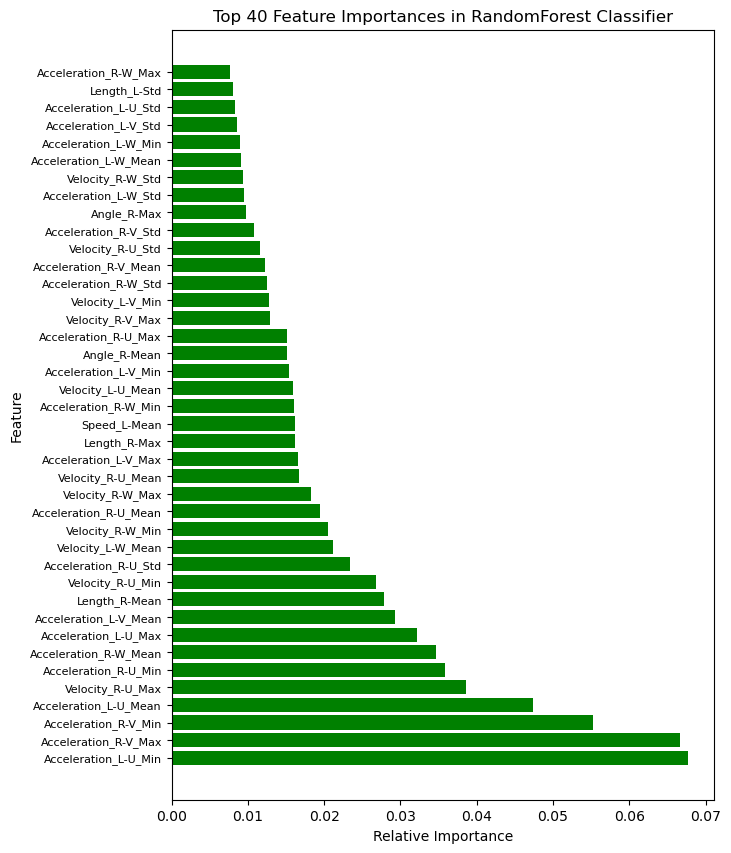

In [134]:
# Plotting only the top 40 feature importances
fig, ax = plt.subplots(figsize=(7, 10))  # Adjust figure size for better readability
ax.barh(range(len(top_importances)), top_importances, color='green')
ax.set_yticks(range(len(top_feature_names)))
ax.set_yticklabels(top_feature_names, fontsize=8)  # Adjust font size for readability
plt.title('Top 40 Feature Importances in RandomForest Classifier')
plt.xlabel('Relative Importance')
plt.ylabel('Feature')
plt.gca().invert_yaxis()  # Flip the order so highest importance is at the top
plt.show()

<Figure size 1000x800 with 0 Axes>

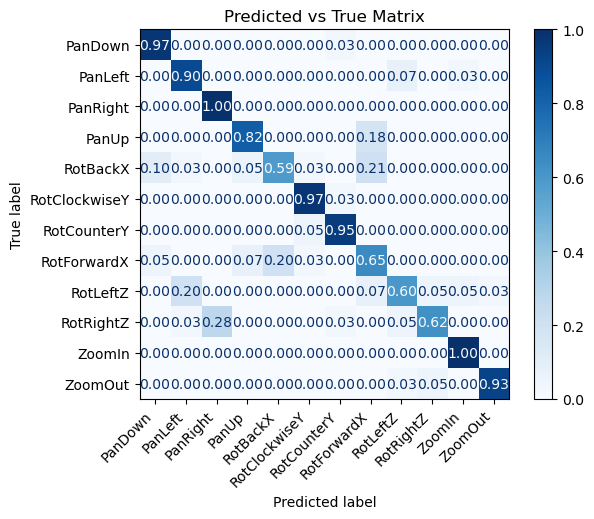

In [135]:
# Confusion matrix to display model predictions against true values
cm = confusion_matrix(y_test, y_pred, normalize='true')

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=gesture_label_encoder.classes_)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
disp.plot(cmap='Blues', values_format='.2f')
plt.xticks(rotation=45, ha="right")
plt.title('Predicted vs True Matrix')
plt.show()